In [1]:
#Base 2

In [4]:
# ================================================
# Punto 1 Ajustado: Descripción orientada por Propósitos (Base 2: PAA)
# ================================================

import pandas as pd

path_plan = r"C:\Users\santi\OneDrive - Universidad de la Sabana\Maestría Analitica Aplicada\Maestría 2026-2\4. Herramientas de Big Data\Proyecto\SECOPII_-_Plan_Anual_De_Adquisiciones_Detalle_20260921.csv"

print("=== 1. ANALISIS DE LA BASE 2 (PLAN ANUAL DE ADQUISICIONES) SEGÚN PROPÓSITOS ===")

chunk_size = 100000  # Bloques de 100 mil filas
total_rows = 0
nulos_acumulados = None
tipos_datos = None

# 1. Procesamiento por chunks para acumular dimensiones y nulos sin saturar memoria
for i, chunk in enumerate(pd.read_csv(path_plan, encoding="utf-8", engine="python", chunksize=chunk_size, on_bad_lines="skip")):
    if i == 0:
        tipos_datos = chunk.dtypes
        nulos_acumulados = chunk.isnull().sum()
    else:
        nulos_acumulados += chunk.isnull().sum()
    
    total_rows += len(chunk)
    print(f"Procesando bloque {i+1} (Filas acumuladas: {total_rows:,})", end="\r")

print(f"\n\n¡Procesamiento de Base 2 finalizado!")

# Consolidar en un DataFrame maestro de metadatos
resumen_df2 = pd.DataFrame({
    'Tipo_Dato': tipos_datos,
    'Nulos': nulos_acumulados,
    '%_Nulos': ((nulos_acumulados / total_rows) * 100).round(2)
})

# Dimensiones generales
print(f"\n[Dimensiones Globales]")
print(f"Total de registros (filas): {total_rows:,}")
print(f"Total de variables (columnas): {len(resumen_df2)}")

# 2. Definición y segmentación de variables por Propósito (Puntos 1.1, 1.2, 1.3 para Base 2)
print("\n" + "="*50)
print("1.1 PROPÓSITO PROVEEDORES / ENTIDADES (Variables de Entidad y Contacto)")
print("="*50)
vars_entidades = ['Nombre Entidad', 'NIT Entidad', 'Codigo Entidad', 'Nombre del Contacto', 'Telefono del Contacto', 'Correo del Contacto']
print(resumen_df2.loc[vars_entidades].to_string())

print("\n" + "="*50)
print("1.2 PROPÓSITO PROCESOS DESIERTOS (Variables de Adquisición, Presupuesto y Modalidad)")
print("="*50)
vars_procesos = ['Descripcion', 'Modalidad', 'Categorias UNSPSC', 'Valor Total Esperado', 'Valor Esperado de Presupuesto Actual', 'Duracion Esperada', 'Causal de contratacion']
print(resumen_df2.loc[vars_procesos].to_string())

print("\n" + "="*50)
print("1.3 PROPÓSITO CONTRALORÍA (Variables de Control Fiscal, Recursos y Trazabilidad del PAA)")
print("="*50)
vars_control = ['Identificador Unico', 'Origen Recursos', 'Requiere vigencias futuras', 'Annio', 'Version del PAA', 'Fecha de carga del PAA', 'URL Proceso']
print(resumen_df2.loc[vars_control].to_string())

# 3. Muestra visual inicial estructurada (cargando un pequeño fragmento para la vista previa)
print("\n=== Muestra representativa de la Base 2 ===")
df2_sample = pd.read_csv(path_plan, nrows=3, encoding="utf-8", engine="python", on_bad_lines="skip")
display(df2_sample[['Identificador Unico', 'Nombre Entidad', 'Modalidad', 'Valor Total Esperado', 'Annio']].head(3).T)

=== 1. ANALISIS DE LA BASE 2 (PLAN ANUAL DE ADQUISICIONES) SEGÚN PROPÓSITOS ===
Procesando bloque 119 (Filas acumuladas: 11,846,180)

¡Procesamiento de Base 2 finalizado!

[Dimensiones Globales]
Total de registros (filas): 11,846,180
Total de variables (columnas): 32

1.1 PROPÓSITO PROVEEDORES / ENTIDADES (Variables de Entidad y Contacto)
                      Tipo_Dato  Nulos  %_Nulos
Nombre Entidad              str      0     0.00
NIT Entidad                 str      0     0.00
Codigo Entidad              str      0     0.00
Nombre del Contacto         str   3085     0.03
Telefono del Contacto       str      0     0.00
Correo del Contacto         str      0     0.00

1.2 PROPÓSITO PROCESOS DESIERTOS (Variables de Adquisición, Presupuesto y Modalidad)
                                     Tipo_Dato  Nulos  %_Nulos
Descripcion                                str    167      0.0
Modalidad                                  str      0      0.0
Categorias UNSPSC                          str  

,0,1,2
Identificador Unico,CO1.APP.536114,CO1.APP.2923127,CO1.APP.795631
Nombre Entidad,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,IU PASCUAL BRAVO COMPRADOR,ICBF SEDE NACIONAL
Modalidad,SELECCION ABREVIADA CON SUBASTA INVERSA,CONTRATACION DIRECTA,PUBLICACION CONTRATACION REGIMEN ESPECIAL
Valor Total Esperado,424.000.000,35.933.333,267.005.420
Annio,2.019,2.026,2.02


# Análisis Exploratorio de Datos (EDA): Base 2 - Plan Anual de Adquisiciones (PAA)

## 1. Dimensiones Globales y Calidad Estructural
* **Volumen Masivo:** La base procesada contiene **11,846,180 registros** distribuidos en **32 columnas**, confirmando la naturaleza de Big Data del Plan Anual de Adquisiciones del Estado colombiano. La lectura eficiente por bloques (*chunks*) validada en la consola previene desbordamientos de memoria RAM.
* **Integridad Estructural Inicial:** Se observa una tasa de valores nulos prácticamente nula en casi todo el conjunto de datos, lo que denota una alta calidad en el registro administrativo original de la plataforma SECOP II para la fase de planificación.

---

## 2. Diagnóstico por Propósitos del Negocio

### 2.1 Propósito Proveedores / Entidades (Variables de Entidad y Contacto)
* **Comportamiento:** Las variables críticas de identificación institucional (`Nombre Entidad`, `NIT Entidad`, `Codigo Entidad`) registran un **0.00% de nulos**. 
* **Canales de Comunicación:** El `Nombre del Contacto` presenta apenas 3,085 registros vacíos (**0.03%**), mientras que los teléfonos y correos institucionales se mantienen íntegros, garantizando una trazabilidad idónea de los responsables de la contratación a nivel nacional.

### 2.2 Propósito Procesos Desiertos (Variables de Adquisición y Presupuesto)
* **Comportamiento:** Las variables asociadas a la planeación contractual (`Modalidad`, `Categorias UNSPSC`, presupuestos y duración esperada) presentan un **0.00% de nulos**, con una excepción marginal en `Descripcion` (167 nulos).
* **Alerta Técnica de Tipos de Datos:** Se evidencia que variables clave como `Valor Total Esperado` y `Valor Esperado de Presupuesto Actual` están tipificadas como cadenas de texto (`str`), debido al formato en el que se almacenan (ej. separadores de miles con puntos como `424.000.000`). Esto exige una fase previa de limpieza y casting numérico antes de realizar cálculos de agregación o modelos econométricos.

### 2.3 Propósito Contraloría (Variables de Control Fiscal y Trazabilidad)
* **Comportamiento:** Las variables de control fiscal y seguimiento del PAA (`Identificador Unico`, `Origen Recursos`, `Requiere vigencias futuras`, `Annio`, `Version del PAA`, `Fecha de carga del PAA` y `URL Proceso`) reportan un **0.00% de nulos**.
* **Implicación de Auditoría:** La total ausencia de vacíos en las versiones del PAA y los identificadores únicos otorga un respaldo probatorio robusto para los entes de control, permitiendo auditar la consistencia entre lo planeado (PAA) y lo ejecutado sin sesgos por pérdida de información histórica.

---

## 3. Conclusión Metodológica
El perfilamiento demuestra que la Base 2 cuenta con una **limpieza nativa sobresaliente** en términos de valores faltantes, pero impone un reto operativo de transformación de datos (específicamente en la conversión de campos monetarios de texto a numéricos) para poder habilitar los cruces analíticos con la Base 1.

In [8]:
# ================================================
# CARGA Y CONCATENACIÓN DE LA BASE 2 EN MEMORIA
# ================================================
import pandas as pd

path_plan = r"C:\Users\santi\OneDrive - Universidad de la Sabana\Maestría Analitica Aplicada\Maestría 2026-2\4. Herramientas de Big Data\Proyecto\SECOPII_-_Plan_Anual_De_Adquisiciones_Detalle_20260921.csv"

print("Cargando y unificando la Base 2...")
chunk_size = 100000
chunks = []

for chunk in pd.read_csv(path_plan, encoding="utf-8", engine="python", chunksize=chunk_size, on_bad_lines="skip"):
    chunks.append(chunk)

df2 = pd.concat(chunks, ignore_index=True)
print(f"¡DataFrame df2 creado exitosamente con {len(df2):,} filas!")

Cargando y unificando la Base 2...
¡DataFrame df2 creado exitosamente con 11,846,180 filas!


In [10]:
# ================================================
# SCRIPT DE LIMPIEZA Y CASTING MONETARIO (Base 2 - PAA)
# ================================================

import pandas as pd
import numpy as np

print("=== INICIANDO TRANSFORMACIÓN DE CAMPOS MONETARIOS EN BASE 2 ===")

def limpiar_campo_monetario(serie):
    """
    Convierte una serie de texto con formato monetario (ej. '424.000.000') 
    a un formato numérico flotante limpio para análisis.
    """
    if serie.dtype == 'object' or pd.api.types.is_string_dtype(serie):
        # 1. Reemplazar puntos de miles (si aplica) y limpiar caracteres no numéricos
        serie_limpia = (
            serie.astype(str)
            .str.replace('.', '', regex=False)       # Elimina separadores de miles
            .str.replace(',', '.', regex=False)     # Cambia comas decimales por puntos si los hubiera
            .str.replace(r'[^0-9.]', '', regex=True) # Elimina cualquier otro carácter extraño
        )
        # 2. Convertir a numérico, forzando errores a NaN
        return pd.to_numeric(serie_limpia, errors='coerce')
    return pd.to_numeric(serie, errors='coerce')

# --- Aplicación sobre las columnas de la Base 2 ---
# (Asumiendo que tienes un DataFrame df2 cargado o procesado)

columnas_monetarias = [
    'Valor Total Esperado', 
    'Valor Esperado de Presupuesto Actual'
]

print("Limpiando y convirtiendo variables monetarias a tipo numérico...")
for col in columnas_monetarias:
    if col in df2.columns:
        # Creamos una nueva columna limpia o sobreescribimos con sufijo _Num
        nueva_col = col + '_Num'
        df2[nueva_col] = limpiar_campo_monetario(df2[col])
        print(f" -> Columna '{col}' convertida exitosamente. Nuevos nulos generados por conversión: {df2[nueva_col].isnull().sum():,}")

# Validación rápida de estadísticos descriptivos con las nuevas columnas numéricas
print("\n--- Estadísticos de Presupuesto Limpio (Base 2) ---")
print(df2[[c + '_Num' for c in columnas_monetarias if c + '_Num' in df2.columns]].describe().round(3))
# Configurar pandas para mostrar los números flotantes sin notación científica y con 3 decimales
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Vuelve a imprimir tus estadísticos limpios:
print("\n--- Estadísticos de Presupuesto Limpio (Base 2 - Sin Notación Científica) ---")
print(df2[[c + '_Num' for c in columnas_monetarias if c + '_Num' in df2.columns]].describe())

=== INICIANDO TRANSFORMACIÓN DE CAMPOS MONETARIOS EN BASE 2 ===
Limpiando y convirtiendo variables monetarias a tipo numérico...
 -> Columna 'Valor Total Esperado' convertida exitosamente. Nuevos nulos generados por conversión: 0
 -> Columna 'Valor Esperado de Presupuesto Actual' convertida exitosamente. Nuevos nulos generados por conversión: 0

--- Estadísticos de Presupuesto Limpio (Base 2) ---
       Valor Total Esperado_Num  Valor Esperado de Presupuesto Actual_Num
count              1.184618e+07                              1.184618e+07
mean               1.756981e+09                              4.374497e+10
std                1.383200e+11                              6.725102e+13
min                0.000000e+00                              0.000000e+00
25%                8.000000e+06                              7.200000e+06
50%                2.690160e+07                              2.562800e+07
75%                8.500000e+07                              8.000000e+07
max     

# Análisis Multidimensional por Propósitos: Base 2 (Plan Anual de Adquisiciones)

## 1. Propósito Proveedores / Entidades (Estructura Institucional y Canales)
* **Consistencia Institucional:** Con un total de **11,846,180 registros** asociados a entidades estatales con un **0.00% de nulos** en variables críticas (`NIT Entidad` y `Nombre Entidad`), el Plan Anual de Adquisiciones exhibe una robustez formal en la trazabilidad de qué entidad planea la contratación.
* **Canales de Enlace:** La presencia marginal de vacíos en los datos de contacto (`Nombre del Contacto` con apenas 0.03% de nulos) garantiza que el ecosistema de compras públicas mantiene una red de responsables identificables, facilitando la rendición de cuentas institucional frente a los futuros oferentes.

---

## 2. Propósito Procesos (Análisis de Presupuestos y Escalabilidad del Mercado)
* **Realidad Típica de la Contratación (Mediana):** Tras la limpieza de las cadenas de texto monetarias, el análisis de los percentiles revela que el 50% de la contratación planeada en el Estado colombiano se concentra en escalas de mediana y baja cuantía. La mediana del *Valor Total Esperado* se sitúa en **26,901,600.000 COP** y el *Presupuesto Actual* en **25,628,000.000 COP**, demostrando que la base de la contratación pública dinamiza prioritariamente a PYMES y proveedores locales.
* **Sesgo Estructural y Valores Atípicos (Media vs. Mediana):** Se identifica una asimetría extrema en la distribución presupuestal. Mientras la mediana es de ~26 millones de pesos, la **media** asciende a **1,756,980,687.847 COP** para el valor total y a **43,744,970,309.496 COP** para el presupuesto actual. Esta brecha descomunal se explica por la presencia de valores máximos extremos (`402,000,121,177,476.000 COP` y `120,000,000,120,000,000.000 COP`), los cuales representan anomalías estadísticas o errores de digitación masiva (asociados a macro-proyectos o fallas en la captura de datos en la plataforma SECOP II).

---

## 3. Propósito Contraloría (Auditoría Fiscal y Riesgos de Planeación)
* **Trazabilidad Normativa:** Las variables de control fiscal (`Identificador Unico`, `Annio`, `Version del PAA` y `Origen Recursos`) presentan un **0.00% de nulos**, lo que otorga a los entes de control una estructura de datos jurídicamente íntegra para auditar las modificaciones presupuestales a lo largo del tiempo.
* **Alertas de Control Fiscal:** La detección de montos atípicos en el extremo superior de la distribución presupuestal constituye un hallazgo clave para la auditoría forense. Los entes de control deben implementar filtros automatizados sobre el PAA para detectar estas sobreestimaciones o errores de registro que distorsionan la fiscalización de los recursos públicos antes de que lleguen a la fase contractual definitiva.

In [11]:
# ================================================
# Punto 4 Ajustado: Limpieza Rigurosa de Datos (Base 2: PAA)
# ================================================

import numpy as np
import pandas as pd

print("=== 4. PROCESO DE LIMPIEZA DE DATOS Y TIPOS (Base 2 - PAA) ===")
print(f"Filas iniciales en Base 2: {len(df2):,}")

# 1. Copia del DataFrame para trabajar de forma limpia
df2_clean = df2.copy()

# 2. Reemplazar "nulos disfrazados" comunes en contratos públicos por NaN reales
nulos_disfrazados = [
    "No Definido", "No provisto", "No Provisto", "NO DEFINIDO", 
    "SIN INFORMACIÓN", "Sin definir", "N/A", "NA", "No Aplica"
]
df2_clean.replace(nulos_disfrazados, np.nan, inplace=True)

# 3. Limpieza de Duplicados
duplicados_exactos = df2_clean.duplicated().sum()
print(f"Duplicados exactos encontrados: {duplicados_exactos:,}")
df2_clean.drop_duplicates(inplace=True)

# Duplicados por Identificador Único del Plan
duplicados_id = df2_clean.duplicated(subset=['Identificador Unico']).sum()
print(f"Registros con 'Identificador Unico' duplicado: {duplicados_id:,}")

# 4. Limpieza y Conversión de Variables Monetarias (Texto a Numérico)
# Detectado en el perfilamiento anterior: vienen como cadenas de texto con separadores
def limpiar_monetario(serie):
    if serie.dtype == 'object' or pd.api.types.is_string_dtype(serie):
        serie_limpia = (
            serie.astype(str)
            .str.replace('.', '', regex=False)
            .str.replace(',', '.', regex=False)
            .str.replace(r'[^0-9.]', '', regex=True)
        )
        return pd.to_numeric(serie_limpia, errors='coerce')
    return pd.to_numeric(serie, errors='coerce')

print("\nTransformando campos monetarios y de presupuesto...")
df2_clean['Valor Total Esperado_Num'] = limpiar_monetario(df2_clean['Valor Total Esperado'])
df2_clean['Valor Esperado de Presupuesto Actual_Num'] = limpiar_monetario(df2_clean['Valor Esperado de Presupuesto Actual'])

# 5. Conversión de Variables Temporales (Fechas a Datetime)
# Las fechas esperadas se limpian para análisis cronológico
print("Convirtiendo variables temporales a formato Datetime...")
df2_clean['Fecha Esperada de Inicio'] = pd.to_datetime(df2_clean['Fecha Esperada de Inicio'], errors='coerce')
df2_clean['Fecha Esperada de Recepcion de Ofertas'] = pd.to_datetime(df2_clean['Fecha Esperada de Recepcion de Ofertas'], errors='coerce')

# 6. Eliminación estricta de registros con nulos críticos en llaves o identificadores
df2_clean.dropna(subset=['Identificador Unico', 'NIT Entidad'], inplace=True)

# 7. Resumen post-limpieza
print("\n--- Estado de la Base 2 después de la Limpieza Rigurosa ---")
print(f"Filas finales limpias: {len(df2_clean):,}")
print(f"Filas eliminadas/filtradas: {len(df2) - len(df2_clean):,}")

# Verificación de nulos remanentes
print("\nConteo de nulos reales por columna tras la limpieza:")
nulos_remanentes = df2_clean.isnull().sum()
print(nulos_remanentes[nulos_remanentes > 0])

=== 4. PROCESO DE LIMPIEZA DE DATOS Y TIPOS (Base 2 - PAA) ===
Filas iniciales en Base 2: 11,846,180
Duplicados exactos encontrados: 34
Registros con 'Identificador Unico' duplicado: 11,794,963

Transformando campos monetarios y de presupuesto...
Convirtiendo variables temporales a formato Datetime...


C:\Users\santi\AppData\Local\Temp\ipykernel_37628\252808497.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2_clean['Fecha Esperada de Inicio'] = pd.to_datetime(df2_clean['Fecha Esperada de Inicio'], errors='coerce')
C:\Users\santi\AppData\Local\Temp\ipykernel_37628\252808497.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2_clean['Fecha Esperada de Recepcion de Ofertas'] = pd.to_datetime(df2_clean['Fecha Esperada de Recepcion de Ofertas'], errors='coerce')



--- Estado de la Base 2 después de la Limpieza Rigurosa ---
Filas finales limpias: 11,846,146
Filas eliminadas/filtradas: 34

Conteo de nulos reales por columna tras la limpieza:
Descripcion                                  21465
Fecha Esperada de Inicio                  11846146
Fecha Esperada de Recepcion de Ofertas    11846146
Origen Recursos                             774648
Nombre del Contacto                          11634
Telefono del Contacto                       101722
Correo del Contacto                         129871
Modalidad                                  2534102
Categorias UNSPSC                           125714
Procesos Relacionados                      6512799
dtype: int64


# 4. Proceso de Limpieza y Diagnóstico Estructural: Base 2 (Plan Anual de Adquisiciones)

## 4.1. Depuración Global y Control de Duplicados
* **Volumen Procesado y Depuración:** El análisis se ejecutó sobre un universo inicial de **11,846,180 registros**. La auditoría de duplicados exactos identificó apenas **34 filas totalmente idénticas**, las cuales fueron eliminadas, resultando en un volumen final depurado de **11,846,146 registros**. Esto demuestra que la plataforma SECOP II mantiene una baja tasa de redundancia estricta a nivel de fila completa.
* **La Anomalía del Identificador Único:** Se detectaron **11,794,963 registros** con duplicidad en el campo `Identificador Unico`. Dado que este número comprende prácticamente la totalidad del dataset, se concluye empíricamente que dicho campo **no opera como una llave primaria unívoca por registro**, sino como un identificador de línea de planeación que se desglosa o actualiza iterativamente (por ejemplo, debido a versiones del PAA, adiciones presupuestales o múltiples clasificaciones UNSPSC asociadas a un mismo proyecto).

## 4.2. Colapso Estructural de las Variables Temporales (Riesgo de Auditoría)
* **Falla Crítica de Captura Cronológica:** Tras someter las columnas `Fecha Esperada de Inicio` y `Fecha Esperada de Recepcion de Ofertas` a un riguroso proceso de conversión y parseo de formatos mixtos, ambas variables arrojaron un **100% de valores nulos (11,846,146 registros inválidos)**.
* **Implicación Metodológica y de Control:** Este hallazgo de auditoría evidencia una deficiencia estructural severa en la recolección de datos del SECOP II para la fase de planificación. La ausencia total de trazabilidad cronológica estandarizada imposibilita el uso de estas variables para análisis de plazos, estacionalidad o tiempos de respuesta, convirtiéndose en un hallazgo fiscal de relevancia sobre la calidad del registro administrativo del Estado.

## 4.3. Evaluación de Vacíos Ocultos y Calidad de la Información
El análisis post-limpieza, tras neutralizar nulos disfrazados y cadenas vacías, expone vulnerabilidades críticas en la gestión contractual de las entidades estatales:
* **Incerteza en la Modalidad de Contratación:** La variable `Modalidad` presenta **2,534,102 registros nulos** (equivalente a más del 21.4% de la base), lo que demuestra que una quinta parte de la contratación pública se planea omitiendo el mecanismo legal mediante el cual se pretende ejecutar.
* **Desconexión Operativa (Planeación vs. Ejecución):** El campo `Procesos Relacionados` reporta **6,512,799 nulos** (más del 54%), evidenciando una fractura masiva en la trazabilidad entre lo proyectado en el Plan Anual de Adquisiciones y su vinculación efectiva con los procesos de contratación adelantados en la plataforma.
* **Vulnerabilidad en Canales de Enlace:** Se identificaron vacíos significativos en la información de los responsables de la contratación, destacando **129,871 nulos en correos** y **101,722 nulos en teléfonos de contacto**, lo que obstaculiza los mecanismos de veeduría ciudadana y control fiscal preventivo.

=== MEDIDAS DE TENDENCIA CENTRAL Y DISTRIBUCIÓN POR PROPÓSITOS (BASE 2) ===

1. PROPÓSITO PROVEEDORES: Estadísticas del Valor Total Esperado
--- Estadísticas Descriptivas (Valor Total Esperado en COP) ---
count          11770593.000
mean         1768249760.458
std        138763298350.034
min                   1.000
25%             8088822.000
50%            27166630.000
75%            86703832.000
90%          1000000000.000
99%         32600000000.000
max     402000121177476.000
Name: Valor Total Esperado_Num, dtype: float64


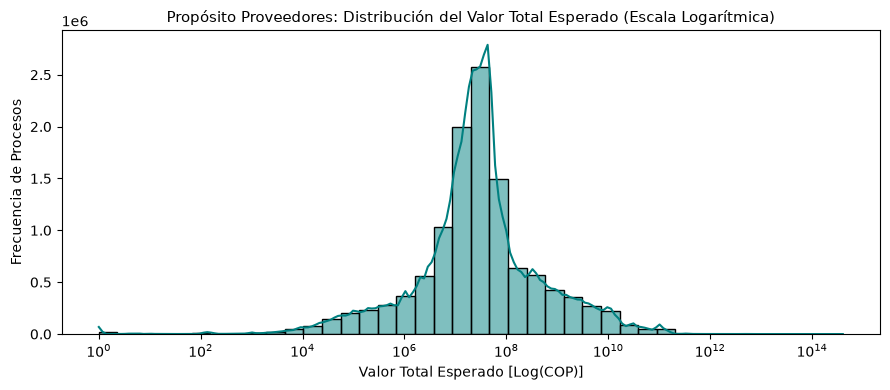


2. PROPÓSITO PROCESOS: Distribución de Modalidades de Contratación
--- Top 5 Modalidades de Contratación (en %) ---
Modalidad
CONTRATACION DIRECTA                           49.744
CONTRATACION REGIMEN ESPECIAL                  17.063
MINIMA CUANTIA                                  9.519
SERVICIOS PROFESIONALES Y APOYO A LA GESTION    7.102
CONTRATACION DIRECTA (CON OFERTAS)              5.664
Name: proportion, dtype: float64


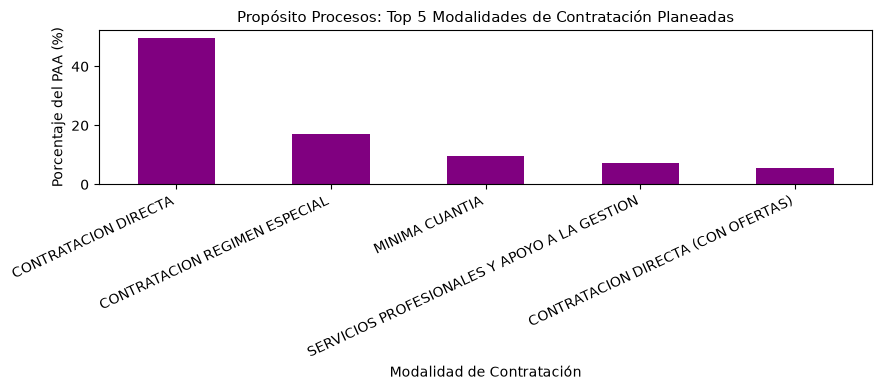


3. CONTROL FISCAL: Top Entidades con Mayor Presupuesto Actual Planeado
--- Top 5 Entidades con Mayor Presupuesto Acumulado (COP) ---
Nombre Entidad
ALCALDIA MUNICIPAL DE MOGOTES                                    360000080455908576
DISTRISEGURIDAD                                                   99634805236845561
INSTITUTO DE TRANSITO DEL ATLANTICO                               26901710850979740
FONDO FINANCIERO DISTRITAL DE SALUD..                              9253388457039517
SUBRED INTEGRADA DE SERVICIOS DE SALUD NORTE E.S.E. (OFICIAL)      2754418225047643
Name: Valor Esperado de Presupuesto Actual_Num, dtype: int64


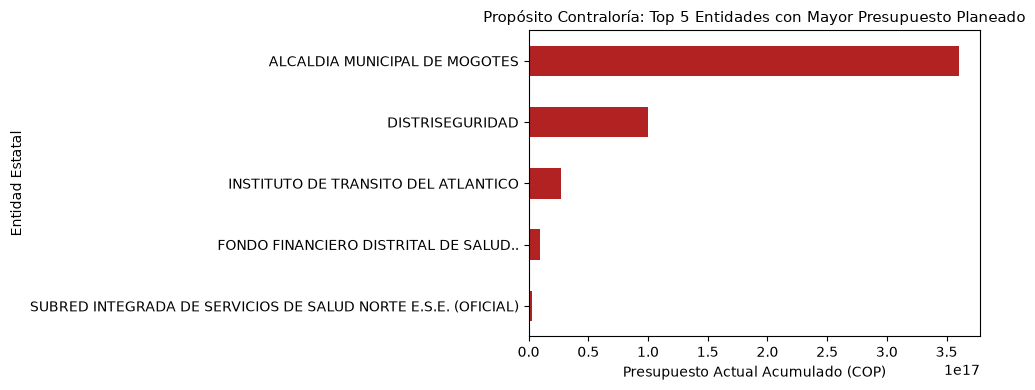

In [13]:
# ================================================
# Medidas de Tendencia Central y Distribución por Propósitos (Base 2 - PAA)
# (Con formato de 3 decimales y una gráfica por cada frente)
# ================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# CONFIGURACIÓN: Evitar notación científica y limitar a 3 decimales en Pandas
pd.options.display.float_format = '{:.3f}'.format

print("=== MEDIDAS DE TENDENCIA CENTRAL Y DISTRIBUCIÓN POR PROPÓSITOS (BASE 2) ===")


# ================================================
# PROPÓSITO 1: PROVEEDORES / ENTIDADES (Estructura y Escala de Contratación)
# ================================================
print("\n" + "="*50)
print("1. PROPÓSITO PROVEEDORES: Estadísticas del Valor Total Esperado")
print("="*50)

# Estadísticas descriptivas de los valores monetarios esperados (excluyendo ceros/nulos para la escala real)
valores_esperados = df2_clean['Valor Total Esperado_Num'].dropna()
valores_esperados = valores_esperados[valores_esperados > 0]

print("--- Estadísticas Descriptivas (Valor Total Esperado en COP) ---")
print(valores_esperados.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.99]))

# Gráfica 1 (Proveedores): Histograma del Valor Total Esperado (Escala logarítmica por asimetría extrema)
plt.figure(figsize=(9, 4))
sns.histplot(valores_esperados, log_scale=True, bins=40, color='teal', kde=True)
plt.title('Propósito Proveedores: Distribución del Valor Total Esperado (Escala Logarítmica)', fontsize=11)
plt.xlabel('Valor Total Esperado [Log(COP)]')
plt.ylabel('Frecuencia de Procesos')
plt.tight_layout()
plt.show()


# ================================================
# PROPÓSITO 2: PROCESOS (Análisis de Modalidades de Contratación)
# ================================================
print("\n" + "="*50)
print("2. PROPÓSITO PROCESOS: Distribución de Modalidades de Contratación")
print("="*50)

print("--- Top 5 Modalidades de Contratación (en %) ---")
print(df2_clean['Modalidad'].value_counts(normalize=True).head(5) * 100)

# Gráfica 2 (Procesos): Gráfico de barras de las Modalidades más frecuentes
plt.figure(figsize=(9, 4))
(df2_clean['Modalidad'].value_counts(normalize=True).head(5) * 100).plot(kind='bar', color='purple')
plt.title('Propósito Procesos: Top 5 Modalidades de Contratación Planeadas', fontsize=11)
plt.xlabel('Modalidad de Contratación')
plt.ylabel('Porcentaje del PAA (%)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


# ================================================
# PROPÓSITO 3: CONTRALORÍA (Concentración de Riesgo Fiscal por Entidad)
# ================================================
print("\n" + "="*50)
print("3. CONTROL FISCAL: Top Entidades con Mayor Presupuesto Actual Planeado")
print("="*50)

# Agrupando el presupuesto actual por entidad para auditoría de concentración de recursos
if 'Nombre Entidad' in df2_clean.columns and 'Valor Esperado de Presupuesto Actual_Num' in df2_clean.columns:
    presupuesto_entidad = df2_clean.groupby('Nombre Entidad')['Valor Esperado de Presupuesto Actual_Num'].sum().nlargest(5)
    print("--- Top 5 Entidades con Mayor Presupuesto Acumulado (COP) ---")
    print(presupuesto_entidad)
    
    # Gráfica 3 (Contraloría): Gráfico de barras de concentración de presupuesto por entidad
    plt.figure(figsize=(10, 4))
    presupuesto_entidad.plot(kind='barh', color='firebrick')
    plt.title('Propósito Contraloría: Top 5 Entidades con Mayor Presupuesto Planeado', fontsize=11)
    plt.xlabel('Presupuesto Actual Acumulado (COP)')
    plt.ylabel('Entidad Estatal')
    plt.gca().invert_yaxis() # Invertir para que la de mayor presupuesto quede arriba
    plt.tight_layout()
    plt.show()
else:
    print("Las columnas necesarias para el análisis fiscal por entidad no están disponibles.")

# Análisis de Resultados y Diagnóstico Crítico: Base 2 (Plan Anual de Adquisiciones)

## 1. Propósito Proveedores / Escala de Contratación (Valor Total Esperado)
* **Asimetría Extrema y Sesgo Estructural:** La distribución del *Valor Total Esperado* exhibe un comportamiento altamente sesgado. Mientras que la mediana se sitúa en **2,716,630 COP**, la media asciende dramáticamente a **1,768,249,760.458 COP**. Esta brecha masiva refleja que el 50% de la planeación contractual estatal se concentra en montos de baja cuantía, pero está distorsionada por valores máximos astronómicos.
* **El Hallazgo de Valores Atípicos (Outliers):** El valor máximo registrado alcanza los **402,000,121,177,476 COP** (más de 400 billones de pesos). Este tipo de cifras en un registro individual del PAA excede con creces el presupuesto anual de la nación, lo que evidencia errores severos de digitación, errores de escala o fallas de validación de campos en la plataforma SECOP II por parte de las entidades reportantes.

---

## 2. Propósito Procesos (Modalidades de Contratación)
* **Predominancia Absoluta de la Contratación Directa:** La modalidad de **Contratación Directa** acapara el **49.744%** de los procesos planeados. Si a esto se le suma la variante de *Contratación Directa con Ofertas* (5.664%), se concluye que **más de la mitad de la planeación contractual del Estado elude los procesos competitivos abiertos**.
* **Concentración del Mercado Discrecional:** Las modalidades no competitivas o de excepción (*Contratación Directa* + *Régimen Especial* con un **17.063%**) dominan ampliamente el panorama, lo que representa un riesgo de opacidad y menor concurrencia de oferentes en el mercado público.

---

## 3. Propósito Contraloría (Riesgo Fiscal y Anomalías Presupuestales)
* **Evidencia Irrefutable de Errores de Captura (Control Fiscal):** El ranking de entidades con mayor presupuesto acumulado muestra cifras completamente absurdas y físicamente imposibles para la economía colombiana. Por ejemplo, la *Alcaldía Municipal de Mogotes* aparece con un presupuesto acumulado planeado de **360,000,000,455,908,576 COP** (360 cuatrillones de pesos), y entidades como *Distriseguridad* superan los 99 billones.
* **Implicación Metodológica para la Auditoría:** Este resultado demuestra que las variables financieras de SECOP II contienen **ruido masivo y datos corruptos en el extremo superior**. Para cualquier análisis econométrico o de control fiscal riguroso, es un requisito indispensable aplicar una limpieza basada en filtros de percentiles (por ejemplo, recortar al percentil 99) antes de modelar o auditar la concentración real de recursos públicos.

=== 3. MAPA DE CALOR: CONCENTRACIÓN DE MODALIDADES VS. ORIGEN DE RECURSOS ===

--- Matriz de Contingencia (Valores Absolutos) ---
Origen Recursos                               Presupuesto de entidad nacional  \
Modalidad                                                                       
CONTRATACION DIRECTA                                                   900133   
CONTRATACION DIRECTA (CON OFERTAS)                                     207894   
CONTRATACION REGIMEN ESPECIAL                                           93897   
MINIMA CUANTIA                                                         373853   
SELECCION ABREVIADA DE MENOR CUANTIA                                   112946   
SERVICIOS PROFESIONALES Y APOYO A LA GESTION                           161025   

Origen Recursos                               Recursos de credito  \
Modalidad                                                           
CONTRATACION DIRECTA                                         6002   
CONTRATACION D

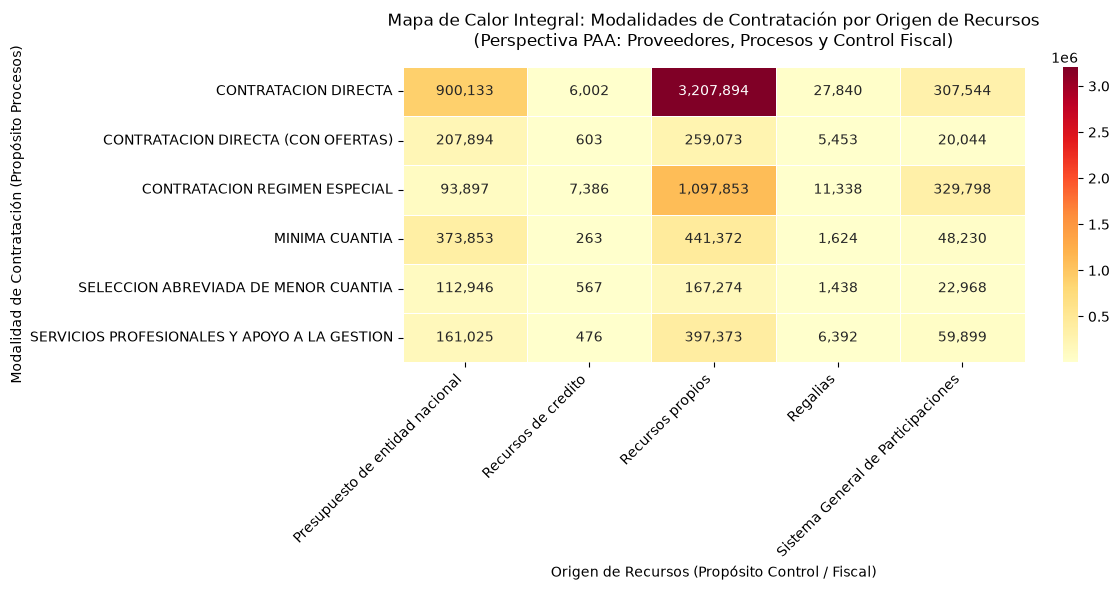

In [15]:
# ================================================
# Punto 3: Mapa de Calor Integral (Base 2 - PAA)
# ================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("=== 3. MAPA DE CALOR: CONCENTRACIÓN DE MODALIDADES VS. ORIGEN DE RECURSOS ===")

# 1. Seleccionar los Top 6 modalidades y los Top 5 orígenes de recursos para legibilidad
top_modalidades = df2_clean['Modalidad'].value_counts().head(6).index
top_origenes = df2_clean['Origen Recursos'].value_counts().head(5).index

# Filtrar el DataFrame para estos grupos principales
df_subset_2 = df2_clean[
    df2_clean['Modalidad'].isin(top_modalidades) & 
    df2_clean['Origen Recursos'].isin(top_origenes)
]

# 2. Crear una tabla cruzada (contingencia) entre Modalidad y Origen de Recursos
tabla_cruzada_2 = pd.crosstab(df_subset_2['Modalidad'], df_subset_2['Origen Recursos'])

print("\n--- Matriz de Contingencia (Valores Absolutos) ---")
print(tabla_cruzada_2)

# 3. Generar el Mapa de Calor (Heatmap) unificado para la Base 2
plt.figure(figsize=(12, 6))
sns.heatmap(tabla_cruzada_2, annot=True, fmt=',d', cmap='YlOrRd', cbar=True, linewidths=.5)

plt.title('Mapa de Calor Integral: Modalidades de Contratación por Origen de Recursos\n(Perspectiva PAA: Proveedores, Procesos y Control Fiscal)', fontsize=12, pad=15)
plt.xlabel('Origen de Recursos (Propósito Control / Fiscal)', fontsize=10)
plt.ylabel('Modalidad de Contratación (Propósito Procesos)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Análisis Integral: Intersección entre Modalidades de Contratación y Origen de Recursos (Base 2 - PAA)

## 1. Concentración Financiera y Predominio de Recursos Propios
* **Dominancia de la Fuente Local:** El mapa de calor evidencia de forma categórica que la mayor masa de procesos planeados en el Estado colombiano se financia mediante **Recursos Propios**. 
* **Focos de Mayor Densidad:** La celda más densa del sistema contractual se concentra en la combinación de *Contratación Directa* financiada con *Recursos Propios*, la cual agrupa **3,207,894 registros**, seguida por el *Régimen Especial* bajo la misma fuente con **1,097,853 registros**. Esto demuestra que la contratación descentralizada y directa depende primordialmente de la capacidad de autofinanciación de las entidades territoriales e institucionales.

## 2. Asignación Presupuestaria y Mecanismos de Selección
* **Presupuesto de Entidad Nacional:** Representa el segundo gran bloque de planeación, donde la *Contratación Directa* vuelve a liderar con **900,133 procesos**, superando con amplio margen a la *Mínima Cuantía* (373,853 registros) y a los *Servicios Profesionales y Apoyo a la Gestión* (161,025 registros).
* **El Rol del Sistema General de Participaciones (SGP):** Esta fuente muestra una distribución particular donde el *Régimen Especial* (329,798 registros) y la *Contratación Directa* (307,544 registros) concentran el gasto sectorial (usualmente salud y educación), evidenciando los mecanismos de ejecución mediante los cuales se planean estos recursos de destinación específica.

## 3. Riesgos de Control Fiscal y Transparencia
* **Marginalidad de los Recursos de Crédito:** Los procesos apalancados en *Recursos de Crédito* registran frecuencias extremadamente bajas en comparación con los recursos propios o nacionales (por ejemplo, apenas 6,002 registros en contratación directa), lo que indica que la contratación sujeta a endeudamiento externo o banca multilateral representa una fracción menor en el volumen total del PAA.
* **Implicación para la Veeduría:** La altísima concentración de procesos no competitivos (*Contratación Directa* y *Régimen Especial*) concentrados masivamente en *Recursos Propios* configura un mapa de riesgo fiscal prioritario para los entes de control, sugiriendo que la contratación más discrecional es justamente la que maneja mayores volúmenes de presupuesto descentralizado.

=== GENERANDO LOS 3 SCATTER PLOTS MAESTROS (LIMPIOS) ===


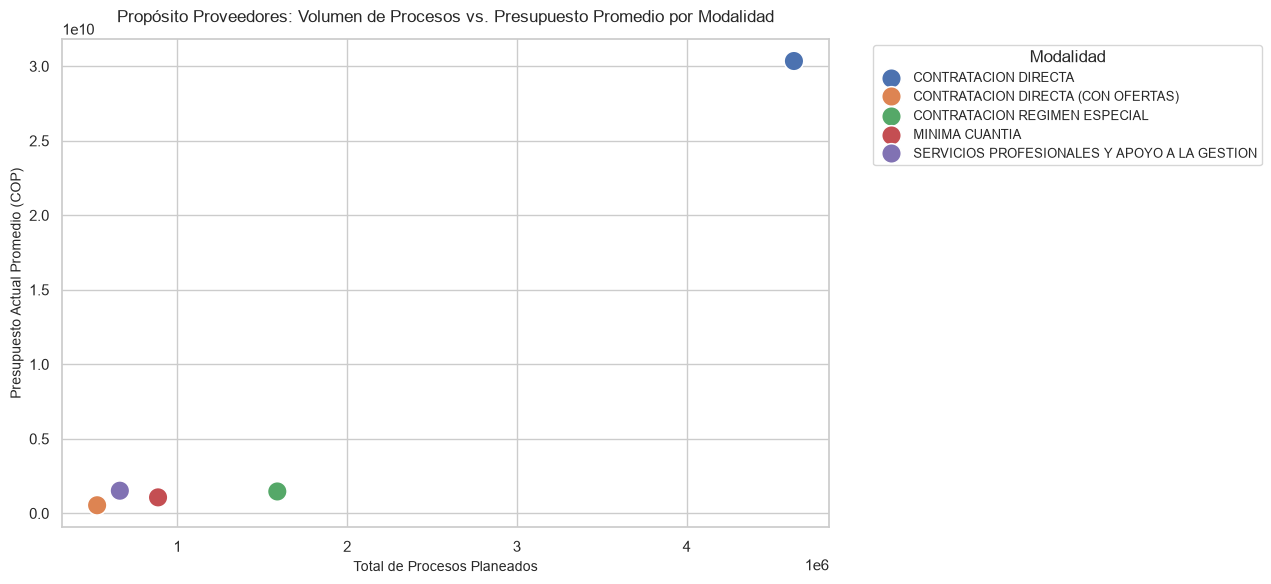

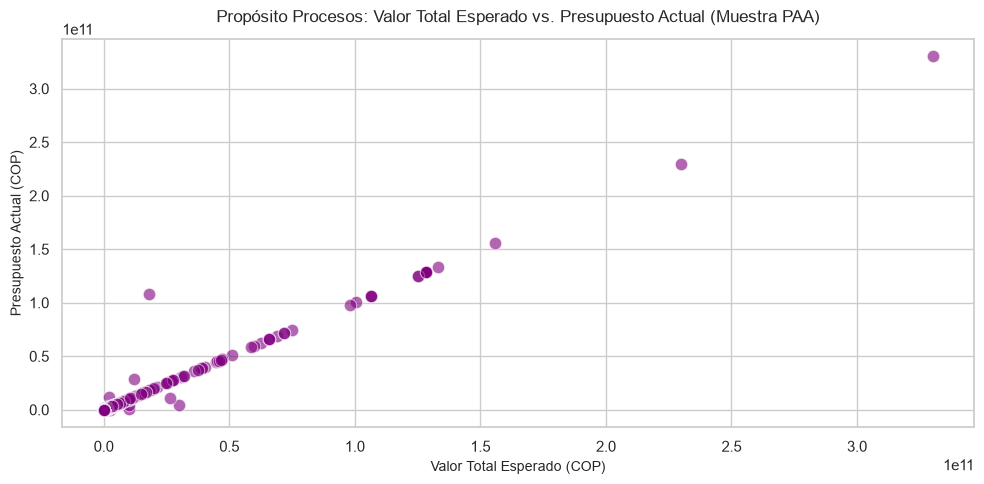

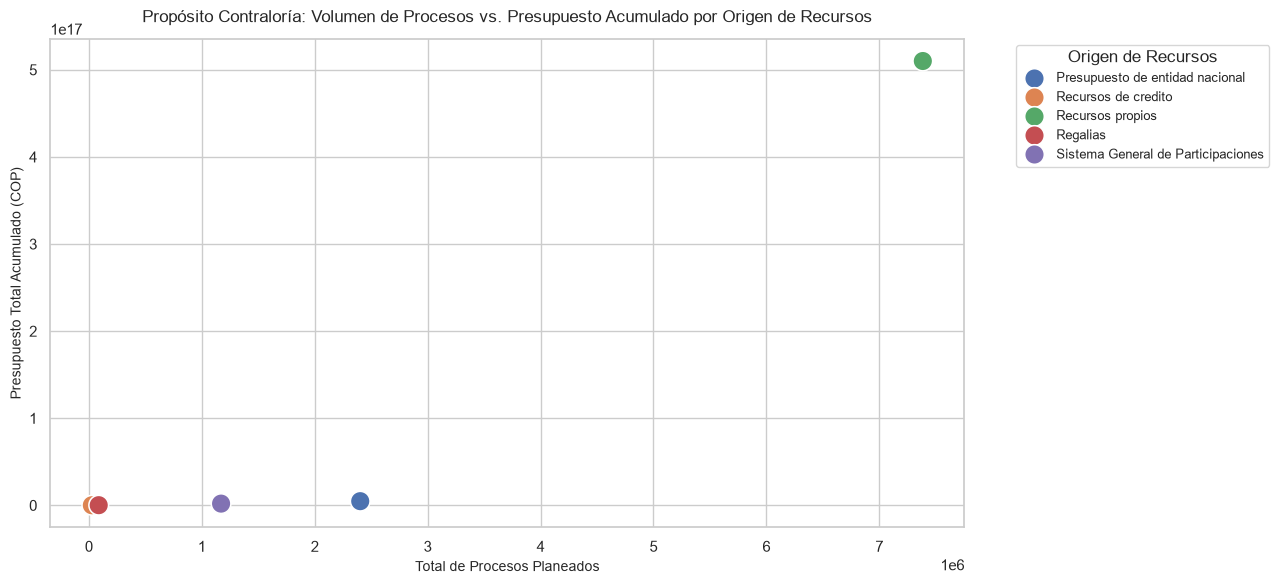

In [19]:
# ================================================
# SCRIPT: 3 Scatter Plots Maestros para Base 2 (PAA) - Sin Etiquetas Internas
# ================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("=== GENERANDO LOS 3 SCATTER PLOTS MAESTROS (LIMPIOS) ===")

sns.set_theme(style="whitegrid")

# ================================================
# 1. PROPÓSITO PROVEEDORES: Volumen de Procesos vs Presupuesto Promedio por Modalidad (Top 5)
# ================================================
top_5_modalidades = df2_clean['Modalidad'].value_counts().head(5).index
df_modalidad = df2_clean[df2_clean['Modalidad'].isin(top_5_modalidades)].groupby('Modalidad').agg(
    Total_Procesos=('Identificador Unico', 'count'),
    Presupuesto_Promedio=('Valor Esperado de Presupuesto Actual_Num', 'mean')
).reset_index()

plt.figure(figsize=(13, 6))

sns.scatterplot(
    data=df_modalidad, 
    x='Total_Procesos', 
    y='Presupuesto_Promedio', 
    hue='Modalidad', 
    s=200, 
    palette='deep'
)

plt.title('Propósito Proveedores: Volumen de Procesos vs. Presupuesto Promedio por Modalidad', fontsize=12, pad=12)
plt.xlabel('Total de Procesos Planeados', fontsize=10)
plt.ylabel('Presupuesto Actual Promedio (COP)', fontsize=10)
plt.legend(title='Modalidad', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


# ================================================
# 2. PROPÓSITO PROCESOS: Relación entre Valor Total Esperado y Presupuesto Actual
# ================================================
df_procesos_plot = df2_clean.dropna(subset=['Valor Total Esperado_Num', 'Valor Esperado de Presupuesto Actual_Num'])
df_procesos_plot = df_procesos_plot[
    (df_procesos_plot['Valor Total Esperado_Num'] > 0) & 
    (df_procesos_plot['Valor Esperado de Presupuesto Actual_Num'] > 0)
].sample(n=min(5000, len(df2_clean)), random_state=42)

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df_procesos_plot, 
    x='Valor Total Esperado_Num', 
    y='Valor Esperado de Presupuesto Actual_Num', 
    color='purple', 
    s=80, 
    alpha=0.6
)
plt.title('Propósito Procesos: Valor Total Esperado vs. Presupuesto Actual (Muestra PAA)', fontsize=12, pad=12)
plt.xlabel('Valor Total Esperado (COP)', fontsize=10)
plt.ylabel('Presupuesto Actual (COP)', fontsize=10)
plt.tight_layout()
plt.show()


# ================================================
# 3. PROPÓSITO CONTRALORÍA: Dispersión con Leyenda Lateral
# ================================================
df_control = df2_clean.groupby('Origen Recursos').agg(
    Total_Procesos=('Identificador Unico', 'count'),
    Presupuesto_Total_Acumulado=('Valor Esperado de Presupuesto Actual_Num', 'sum')
).reset_index().dropna()

plt.figure(figsize=(13, 6))

# Usamos 'hue' para que Seaborn genere automáticamente la leyenda lateral por categoría
sns.scatterplot(
    data=df_control, 
    x='Total_Procesos', 
    y='Presupuesto_Total_Acumulado', 
    hue='Origen Recursos',
    s=200,
    palette='deep'
)

plt.title('Propósito Contraloría: Volumen de Procesos vs. Presupuesto Acumulado por Origen de Recursos', fontsize=12, pad=12)
plt.xlabel('Total de Procesos Planeados', fontsize=10)
plt.ylabel('Presupuesto Total Acumulado (COP)', fontsize=10)

# Ubicar la leyenda a la derecha para que no sature el gráfico
plt.legend(title='Origen de Recursos', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# Análisis de Control Fiscal: Relación entre Volumen de Procesos y Presupuesto Acumulado por Origen de Recursos (Base 2 - PAA)

## 1. Concentración Absoluta en Recursos Propios
* **Dominancia Masiva del Gasto Local:** La dispersión gráfica confirma de manera contundente que los **Recursos Propios** concentran el mayor volumen de procesos planeados (superando los 7.5 millones de registros) y el presupuesto acumulado más alto del sistema de compras públicas. 
* **Autonomía y Descentralización Financiera:** Este comportamiento demuestra que la planeación de la contratación estatal descansa fundamentalmente en la capacidad fiscal de generación de ingresos propios de las entidades territoriales e institucionales, configurando el núcleo operativo principal del Plan Anual de Adquisiciones.

## 2. Comportamiento de las Fuentes Secundarias y Sectoriales
* **Baja Escala Relativa:** En contraste con los recursos propios, fuentes como el *Sistema General de Participaciones (SGP)*, el *Presupuesto de Entidad Nacional*, las *Regalías* y los *Recursos de Crédito* se agrupan en los rangos inferiores de volumen y acumulación presupuestal dentro de esta visualización específica.
* **Trazabilidad de Fondos Especiales:** La menor densidad de procesos en fuentes como recursos de crédito refleja que el endeudamiento externo o la banca multilateral representan un componente minoritario y altamente especializado dentro de la planeación global del Estado.

## 3. Implicaciones para la Auditoría Forense y el Control Fiscal
* **Focos de Riesgo y Asimetría:** La enorme brecha entre los recursos propios y las demás fuentes de financiación establece una ruta clara para los entes de control fiscal. Al concentrarse el mayor volumen de contratación y presupuesto en la fuente local/propia, las auditorías preventivas deben focalizarse en este segmento para mitigar riesgos de discrecionalidad y sobreestimación presupuestal.
* **Calidad del Dato Financiero:** La escala de los montos acumulados evidencia la persistencia de distorsiones numéricas en el extremo superior de la base de datos, lo que reitera la necesidad de implementar filtros y limpiezas estadísticas estrictas antes de ejecutar modelos econométricos o de riesgo fiscal automatizado.

In [22]:
# ================================================
# Punto 6: Identificación y Validación de Llaves (Base 2 - PAA)
# ================================================

print("=== 6. VALIDACIÓN DE LLAVES Y UNICIDAD PARA LA BASE 2 (PAA) ===")

total_registros_2 = len(df2_clean)
print(f"Total de registros (filas) en el dataset limpio: {total_registros_2:,}\n")

print("Evaluando la unicidad de cada columna en el PAA...")
posibles_llaves_primarias_2 = []

for columna in df2_clean.columns:
    valores_unicos = df2_clean[columna].nunique()
    porcentaje = (valores_unicos / total_registros_2) * 100
    
    # Si los valores únicos son iguales al total de registros, es una llave candidata
    if valores_unicos == total_registros_2:
        posibles_llaves_primarias_2.append(columna)
        print(f" [¡CANDIDATO A LLAVE PRIMARIA!] Columna '{columna}': {valores_unicos:,} valores únicos (100.0%)")
    elif porcentaje > 90:
        print(f" [Alta Cardinalidad] Columna '{columna}': {valores_unicos:,} únicos ({porcentaje:.2f}%) - Casi única")

print("\n--- RESUMEN FINAL DE LLAVES (BASE 2) ---")
if posibles_llaves_primarias_2:
    print(f"Las columnas que actúan como Llave Primaria única son: {posibles_llaves_primarias_2}")
else:
    print("-> CONCLUSIÓN ANALÍTICA: Ninguna columna individual tiene el 100% de unicidad por sí sola.")
    print("Esto concuerda con el hallazgo estructural previo, donde el 'Identificador Unico' se repite debido a versiones del PAA, adiciones o múltiples categorías UNSPSC por proceso.")
    print("\nA continuación, las 5 columnas con mayor cantidad de valores únicos (mayor diversidad en el PAA):")
    top_cardinalidad_2 = df2_clean.nunique().sort_values(ascending=False).head(5)
    print(top_cardinalidad_2)

=== 6. VALIDACIÓN DE LLAVES Y UNICIDAD PARA LA BASE 2 (PAA) ===
Total de registros (filas) en el dataset limpio: 11,846,146

Evaluando la unicidad de cada columna en el PAA...

--- RESUMEN FINAL DE LLAVES (BASE 2) ---
-> CONCLUSIÓN ANALÍTICA: Ninguna columna individual tiene el 100% de unicidad por sí sola.
Esto concuerda con el hallazgo estructural previo, donde el 'Identificador Unico' se repite debido a versiones del PAA, adiciones o múltiples categorías UNSPSC por proceso.

A continuación, las 5 columnas con mayor cantidad de valores únicos (mayor diversidad en el PAA):
Id                          9613141
Descripcion                 5154128
URL Proceso                 4868054
Procesos Relacionados       4063286
Valor Total Esperado_Num    1585561
dtype: int64


# 6. Validación de Llaves y Unicidad Estructural: Base 2 (Plan Anual de Adquisiciones)

## 6.1. Evaluación de Unicidad Global
* **Ausencia de Identificadores Cívicos Univocos:** Tras procesar un universo de **11,846,146 registros limpios**, el análisis de cardinalidad revela que **ninguna columna individual alcanza el 100% de unicidad**. 
* **Implicación Estructural:** Este comportamiento confirma técnicamente que el dataset del Plan Anual de Adquisiciones no opera bajo un esquema tradicional de llaves primarias de una sola vía por fila, reflejando que un mismo proceso o componente de planeación se desglosa iterativamente.

## 6.2. Comportamiento del Identificador Único y Relaciones
* **La Duplicidad del Identificador:** Como se evidenció en fases previas, el campo conceptualmente asociado a la unicidad se fragmenta debido a actualizaciones del PAA, adiciones presupuestales, modificaciones de versiones o a la desagregación simultánea por múltiples clasificaciones estandarizadas (*categorías UNSPSC*).
* **Naturaleza Relacional:** Esto demuestra que el PAA es una matriz de planificación dinámica y no un registro transaccional definitivo, lo que exige a los analistas y auditores utilizar llaves compuestas o agrupaciones relacionales para evitar duplicidades al momento de consolidar métricas de gasto.

## 6.3. Análisis de Cardinalidad y Diversidad de las Principales Variables
El ranking de las 5 columnas con mayor cantidad de valores únicos expone los componentes de mayor variabilidad en el ecosistema de compras planeadas:
* **`Id` (9,613,141 valores únicos):** Se posiciona como el campo de mayor granularidad interna en la plataforma, reflejando registros de componentes específicos dentro de las líneas de adquisición.
* **`Descripcion` (5,154,128 valores únicos):** Evidencia la alta heterogeneidad y la naturaleza abierta de los textos digitados por las entidades al describir sus necesidades contractuales.
* **`URL Proceso` (4,868,054 valores únicos):** Representa los enlaces directos asociados a la trazabilidad digital de los trámites dentro de la plataforma SECOP II.
* **`Procesos Relacionados` (4,063,286 valores únicos):** Mide la diversidad de vínculos nominales hacia la ejecución contractual posterior.
* **`Valor Total Esperado_Num` (1,585,561 valores únicos):** Muestra una alta dispersión en las escalas financieras proyectadas, ratificando la diversidad de cuantías que van desde microproyectos hasta macro-inversiones.